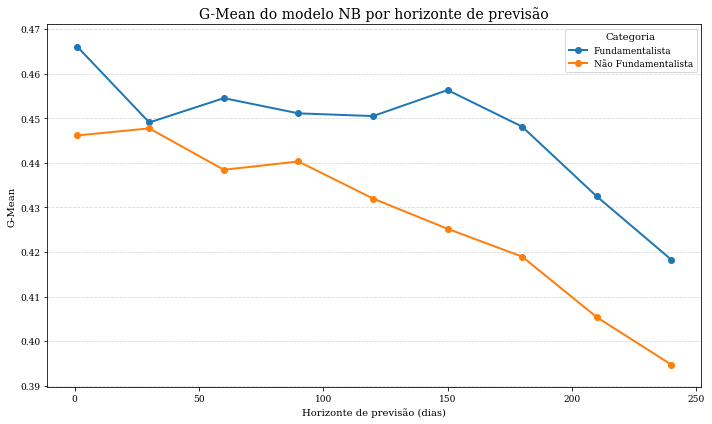

   modelo     valor   fh categoria
0      NB  0.466086    1      fund
1      NB  0.446152    1  nao_fund
2      NB  0.449062   30      fund
3      NB  0.447734   30  nao_fund
4      NB  0.454518   60      fund
5      NB  0.438450   60  nao_fund
6      NB  0.451104   90      fund
7      NB  0.440308   90  nao_fund
8      NB  0.450496  120      fund
9      NB  0.431993  120  nao_fund
10     NB  0.456328  150      fund
11     NB  0.425202  150  nao_fund
12     NB  0.448107  180      fund
13     NB  0.418958  180  nao_fund
14     NB  0.432469  210      fund
15     NB  0.405376  210  nao_fund
16     NB  0.418264  240      fund
17     NB  0.394723  240  nao_fund


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_desempenho(
    modelo,
    caminho_csv,
    categorias,
    horizontes,
    tipo='bar',
    metrica='Accuracy',
    ylim=None
):
    """
    Gera um gráfico de desempenho por horizonte de previsão, podendo alternar entre métricas.

    Parâmetros:
        modelo (str): Nome do modelo (ex: 'NB', 'RF', etc.)
        caminho_csv (str): Caminho do arquivo CSV consolidado.
        categorias (list): Lista de categorias (ex: ['fund', 'nao_fund']).
        horizontes (list): Lista de horizontes (ex: [1,30,60,...]).
        tipo (str): Tipo de gráfico ('bar' ou 'line').
        metrica (str): Nome da métrica a exibir ('AUC', 'Accuracy', 'Kappa', 'G-Mean', 'Recall', 'Precision').
        ylim (tuple): Intervalo do eixo Y, ex: (0.5, 1.0) ou (0, 1).
    """

    # === Leitura dos dados ===
    df = pd.read_csv(caminho_csv)

    # Verifica se a métrica existe no CSV
    if metrica not in df.columns:
        raise ValueError(f"A métrica '{metrica}' não foi encontrada no CSV. Colunas disponíveis: {list(df.columns)}")

    # === Agregação dos resultados ===
    df_results = pd.DataFrame()
    for fh in horizontes:
        for cat in categorias:
            df_filtered = df[(df['categoria'] == cat) & (df['fh'] == fh)]
            valor_medio = df_filtered[metrica].mean()
            
            df_results = pd.concat([
                df_results,
                pd.DataFrame({
                    'modelo': [modelo],
                    'valor': [valor_medio],
                    'fh': [fh],
                    'categoria': [cat]
                })
            ], ignore_index=True)

    # === Tabela pivotada (fh nas linhas, categorias nas colunas) ===
    pivot_df = df_results.pivot(index='fh', columns='categoria', values='valor')

    # === Gráfico ===
    plt.figure(figsize=(10, 6))
    
    if tipo == 'bar':
        pivot_df.plot(kind='bar', width=0.8, ax=plt.gca())
    elif tipo == 'line':
        pivot_df.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())
    else:
        raise ValueError("O parâmetro 'tipo' deve ser 'bar' ou 'line'")

    # === Aparência ===
    plt.title(f'{metrica} do modelo {modelo} por horizonte de previsão', fontsize=14)
    plt.xlabel('Horizonte de previsão (dias)')
    plt.ylabel(metrica)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='Categoria', labels=['Fundamentalista', 'Não Fundamentalista'])
    plt.ylim(df_results['valor'].min() - 0.005, df_results['valor'].max() + 0.005)
    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.show()
    print(df_results)


# === Exemplo de uso ===
plot_desempenho(
    modelo="NB",
    caminho_csv="resultados/resultados_consolidados_20251113_010654.csv",
    categorias=['fund', 'nao_fund'],
    horizontes=[1, 30, 60, 90, 120, 150, 180, 210, 240],
    tipo='line',       # 'bar' ou 'line'
    metrica='G-Mean',  # AUC, Accuracy, Kappa, G-Mean, Recall, Precision
    # ylim=(-0.2, 0.2)
)

In [2]:
df_vmob = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
    # ensure the column is datetime-like before using .dt
if not pd.api.types.is_datetime64_any_dtype(df_vmob['Data_Referencia']):
    df_vmob['Data_Referencia'] = pd.to_datetime(df_vmob['Data_Referencia'], errors='coerce')

In [22]:
df_vmob[df_vmob['Segmento'] == 'Bovespa Mais']
# df_vmob['Segmento'].unique()

,CNPJ_Companhia,Data_Referencia,Versao,ID_Documento,Valor_Mobiliario,Sigla_Classe_Acao_Preferencial,Classe_Acao_Preferencial,Codigo_Negociacao,Composicao_BDR_Unit,Mercado,Sigla_Entidade_Administradora,Entidade_Administradora,Data_Inicio_Negociacao,Data_Fim_Negociacao,Segmento,Data_Inicio_Listagem,Data_Fim_Listagem
219,45.987.245/0001-92,2023-01-01,2,128625,Ações Ordinárias,NaN,NaN,BAHI3,NaN,Bolsa,B3,"B3 S.A. - Brasil, Bolsa, Balcão.",2018-01-26,NaN,Bovespa Mais,1974-01-02,NaN
227,51.128.999/0001-90,2023-01-01,1,124621,Ações Ordinárias,NaN,NaN,NUTR3,NaN,Bolsa,B3,"B3 S.A. - Brasil, Bolsa, Balcão.",2008-02-13,NaN,Bovespa Mais,2008-02-13,NaN


Plotting performance for 58 securities.
Securities: ['CYRE3' 'DXCO3' 'ABCB4' 'ITUB4' 'BBAS3' 'LOGN3' 'TRPL4' 'SAPR4' 'AMER3'
 'FESA4' 'UNIP6' 'POSI3' 'BBDC4' 'CCRO3' 'MILS3' 'LREN3' 'MYPK3' 'TOTS3'
 'CIEL3' 'DIRR3' 'MDIA3' 'FHER3' 'PETR4' 'RADL3' 'VALE3' 'ELET3' 'GGBR4'
 'BRSR6' 'PDGR3' 'HYPE3' 'BBDC3' 'HBOR3' 'USIM3' 'SLCE3' 'NEXP3' 'PETR3'
 'BRFS3' 'RENT3' 'EQTL3' 'RSID3' 'ELET6' 'MULT3' 'USIM5' 'CSUD3' 'CMIG4'
 'GRND3' 'GGBR3' 'CMIG3' 'KEPL3' 'ITUB3' 'CPFE3' 'GFSA3' 'ODPV3' 'BEEF3'
 'ENBR3' 'EMBR3' 'POMO4' 'ALPA4']
Securities excluded: {'CARD3', 'DTEX3', 'BBRK3', 'MRFG3', 'BTOW3', 'LEVE3'}


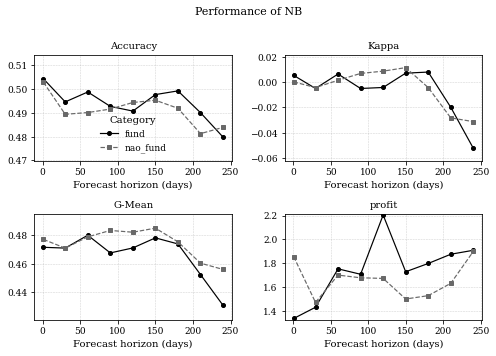

   model     value   fh  category
0     NB  1.339274    1      fund
1     NB  1.855816    1  nao_fund
2     NB  1.433203   30      fund
3     NB  1.473510   30  nao_fund
4     NB  1.754383   60      fund
5     NB  1.702107   60  nao_fund
6     NB  1.708920   90      fund
7     NB  1.679505   90  nao_fund
8     NB  2.204641  120      fund
9     NB  1.674361  120  nao_fund
10    NB  1.729970  150      fund
11    NB  1.502171  150  nao_fund
12    NB  1.799337  180      fund
13    NB  1.530151  180  nao_fund
14    NB  1.876459  210      fund
15    NB  1.633258  210  nao_fund
16    NB  1.909597  240      fund
17    NB  1.899946  240  nao_fund


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_conference_metrics(
    model,
    csv_path,
    categories,
    horizons,
    plot_type='line',
    metrics=('Accuracy', 'Kappa', 'AUC', 'G-Mean'),
    tickers=None,
    save_path=None
):
    """
    Creates a 2x2 figure with the main performance metrics (Accuracy, Kappa, AUC, G-Mean)
    in grayscale and publication-quality style (conference-ready).

    Each metric has an automatically scaled Y-axis based on its observed range.

    Parameters:
        model (str): Model name (e.g., 'NB', 'RF', etc.)
        csv_path (str): Path to the consolidated CSV file.
        categories (list): List of categories (e.g., ['fund', 'non_fund']).
        horizons (list): List of forecast horizons (e.g., [1, 30, 60, ...]).
        plot_type (str): Type of plot ('line' or 'bar').
        metrics (tuple): Metrics to display (default: Accuracy, Kappa, AUC, G-Mean).
        save_path (str): Optional path to save the figure (e.g., 'figures/performance.pdf').
    """

    # --- Global style settings (conference style) ---
    mpl.rcParams.update({
        'font.family': 'serif',
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 10,
        'legend.fontsize': 9,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'axes.edgecolor': 'black',
        'axes.linewidth': 0.8,
        'pdf.fonttype': 42,  # keep text as vector fonts
        'ps.fonttype': 42
    })

    df = pd.read_csv(csv_path)

    fig, axes = plt.subplots(2, 2, figsize=(7, 5))
    axes = axes.flatten()

    # --- Grayscale style variations ---
    gray_styles = [
        {'color': 'black', 'linestyle': '-', 'marker': 'o'},
        {'color': 'dimgray', 'linestyle': '--', 'marker': 's'}
    ]
    df_vmob = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
    # ensure the column is datetime-like before using .dt
    if not pd.api.types.is_datetime64_any_dtype(df_vmob['Data_Referencia']):
        df_vmob['Data_Referencia'] = pd.to_datetime(df_vmob['Data_Referencia'], errors='coerce')

    papeis = df_vmob[df_vmob['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
    papeis_anteriores = df['base'].unique()
    df = df[df['base'].isin(papeis)]
    df = df[~df['base'].isin(['LEVE3'])]  # Exclude LEVE3 and LEVE4 due to not ajusted prices
    print(f"Plotting performance for {len(df['base'].unique())} securities.")
    print(f"Securities: {df['base'].unique()}")
    print(f"Securities excluded: {set(papeis_anteriores) - set(df['base'].unique())}")

    if tickers is not None:
        df = df[df['base'].isin(tickers)]
        print(f"Filtered to {len(df['base'].unique())} specified tickers.")
    for ax, metric in zip(axes, metrics):
        if metric not in df.columns:
            print(f"⚠️ Metric '{metric}' not found in the CSV file. Skipping.")
            continue

        # --- Aggregate results for each horizon/category ---
        df_results = pd.DataFrame()
        for fh in horizons:
            for cat in categories:
                df_filtered = df[(df['categoria'] == cat) & (df['fh'] == fh)]
                mean_value = df_filtered[metric].mean()
                df_results = pd.concat([
                    df_results,
                    pd.DataFrame({
                        'model': [model],
                        'value': [mean_value],
                        'fh': [fh],
                        'category': [cat]
                    })
                ], ignore_index=True)

        pivot_df = df_results.pivot(index='fh', columns='category', values='value')

        # --- Plotting ---
        if plot_type == 'line':
            for i, col in enumerate(pivot_df.columns):
                style = gray_styles[i % len(gray_styles)]
                ax.plot(pivot_df.index, pivot_df[col], label=col,
                        linewidth=1.2, markersize=4, **style)
        elif plot_type == 'bar':
            bar_colors = ['gray', 'lightgray']
            pivot_df.plot(kind='bar', ax=ax, width=0.7, color=bar_colors[:len(pivot_df.columns)])
        else:
            raise ValueError("Parameter 'plot_type' must be either 'line' or 'bar'")

        # --- Dynamic Y-axis limits ---
        min_val = df_results['value'].min()
        max_val = df_results['value'].max()
        margin = 0.01
        ax.set_ylim(min_val - margin, max_val + margin)

        # --- Aesthetic adjustments ---
        ax.set_title(metric)
        ax.set_xlabel('Forecast horizon (days)')
        ax.set_ylabel('')
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

        if ax == axes[0]:
            ax.legend(title='Category', frameon=False, loc='best')
        else:
            ax.legend().set_visible(False)

    fig.suptitle(f'Performance of {model}', fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # --- Save or display ---
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
        plt.close(fig)
        print(f"Figure saved at: {save_path}")
    else:
        plt.show()

    
    print(df_results)

model = "NB"
atraso = 5# A task EvaluatePrequentialProfit2 inverte os labels fund e nao_fund, com isso, consegue-se melhor profit
plot_conference_metrics(
    model=model,
    csv_path=f"resultados/resultados_{model}_atraso_{atraso}.csv",
    categories=['fund', 'nao_fund'],
    horizons=[1, 30, 60, 90, 120, 150, 180, 210, 240],
    plot_type='line',
    metrics=('Accuracy', 'Kappa', 'G-Mean',  'profit',),
    # tickers=[
    # "ITUB4",  # Financeiro – Banco privado
    # # "BBAS3",  # Financeiro – Banco público
    # "BBDC4",  # Financeiro – Banco privado
    # "EQTL3",  # Energia elétrica
    # "TRPL4",  # Transmissão de energia
    # "VALE3",  # Mineração – Commodities
    # "PETR4",  # Petróleo e gás
    # "LREN3",  # Varejo – Consumo
    # "RADL3",  # Farmácias – Consumo defensivo
    # "TOTS3",  # Tecnologia / Software],
    # ],
#     tickers=[
#     "ITUB3",  # Financeiro – Banco privado
#     "BRSR6",  # Financeiro – Banco regional / foco em dividendos
#     "EQTL3",  # Energia – distribuição / utilities
#     "ENBR3",  # Energia – geração
#     "ELET6",  # Energia – elétrica integrada
#     "GGBR4",  # Siderurgia – commodities
#     "USIM5",  # Siderurgia – indústria pesada
#     "RENT3",  # Serviços – locação de veículos
#     "MULT3",  # Shoppings – renda recorrente
#     "TOTS3",  # Tecnologia – software corporativo
# ],
# tickers=[
#     "BBDC3",  # Bancos – solidez e histórico de dividendos
#     # "BBAS3",  # Bancos – forte geração de caixa
#     "TRPL4",  # Energia – transmissão, baixo risco
#     "ENBR3", # Energia – dividendos elevados
#     "RADL3",  # Consumo defensivo – farmácias
#     "MULT3",  # Shoppings – renda recorrente
#     "GGBR3",  # Siderurgia
#     "LREN3",  # Varejo – Consumo
#     "AMER3",  # Varejo – Consumo
#     "DIRR3",  # Construção civil
#     "PETR4",  # Commodities – petróleo
# ],
# tickers=[
#     "LREN3",  # Varejo – moda (consumo discricionário)
#     "AMER3",  # Varejo – altamente dependente de crédito
#     "CYRE3",  # Construção civil – forte impacto dos juros
#     "DIRR3",  # Construção civil
#     "HBOR3",  # Incorporação imobiliária
#     "PDGR3",  # Incorporação – alta alavancagem
#     "ALPA4",  # Varejo – calçados e vestuário
#     "GRND3",  # Varejo – calçados
#     "POSI3",  # Bens duráveis – eletrônicos
#     "MULT3",  # Shoppings – consumo + custo da dívida
# ],
# tickers=[
#     "VALE3",  # Materiais Básicos (Mineração) - Rank Vol: 1
#     "PETR4",  # Petróleo e Gás - Rank Vol: 2
#     "BBDC4",  # Financeiro (Bancos) - Rank Vol: 3
#     "RENT3",  # Industrial (Locação) - Rank Vol: 7
#     "ELET3",  # Utilidade Pública (Energia) - Rank Vol: 8
#     "LREN3",  # Consumo Cíclico (Varejo Moda) - Rank Vol: 9
#     "AMER3",  # Varejo Online (Volatilidade) - Rank Vol: 12
#     "RADL3",  # Saúde (Farmácias/Defensivo) - Rank Vol: 14
#     "BRFS3",  # Consumo Não-Cíclico (Alimentos) - Rank Vol: 15
#     "CYRE3"   # Imobiliário (Construção) - Rank Vol: 21
# ],
tickers=None,

    # ylim=(0.4, 1.0),
    # save_path='figuras/desempenho_nb.pdf'
)



Plotting performance for 58 securities.
Securities: ['CYRE3' 'DXCO3' 'ABCB4' 'ITUB4' 'BBAS3' 'LOGN3' 'TRPL4' 'SAPR4' 'AMER3'
 'FESA4' 'UNIP6' 'POSI3' 'BBDC4' 'CCRO3' 'MILS3' 'LREN3' 'MYPK3' 'TOTS3'
 'CIEL3' 'DIRR3' 'MDIA3' 'FHER3' 'PETR4' 'RADL3' 'VALE3' 'ELET3' 'GGBR4'
 'BRSR6' 'PDGR3' 'HYPE3' 'BBDC3' 'HBOR3' 'USIM3' 'SLCE3' 'NEXP3' 'PETR3'
 'BRFS3' 'RENT3' 'EQTL3' 'RSID3' 'ELET6' 'MULT3' 'USIM5' 'CSUD3' 'CMIG4'
 'GRND3' 'GGBR3' 'CMIG3' 'KEPL3' 'ITUB3' 'CPFE3' 'GFSA3' 'ODPV3' 'BEEF3'
 'ENBR3' 'EMBR3' 'POMO4' 'ALPA4']
Securities excluded: {'BTOW3', 'MRFG3', 'BBRK3', 'CARD3', 'LEVE3', 'DTEX3'}


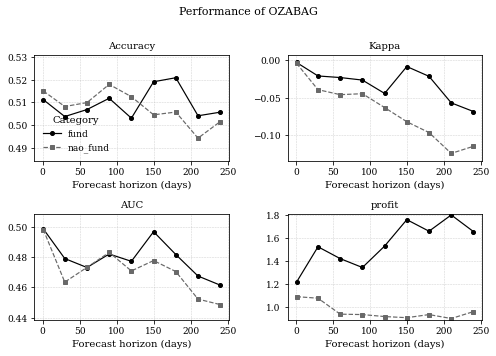

     model     value   fh  category
0   OZABAG  1.214298    1      fund
1   OZABAG  1.088283    1  nao_fund
2   OZABAG  1.520867   30      fund
3   OZABAG  1.074875   30  nao_fund
4   OZABAG  1.418364   60      fund
5   OZABAG  0.936448   60  nao_fund
6   OZABAG  1.341225   90      fund
7   OZABAG  0.932900   90  nao_fund
8   OZABAG  1.526967  120      fund
9   OZABAG  0.915770  120  nao_fund
10  OZABAG  1.756253  150      fund
11  OZABAG  0.905892  150  nao_fund
12  OZABAG  1.655949  180      fund
13  OZABAG  0.932867  180  nao_fund
14  OZABAG  1.796968  210      fund
15  OZABAG  0.898650  210  nao_fund
16  OZABAG  1.652691  240      fund
17  OZABAG  0.958379  240  nao_fund


In [66]:
model = "OZABAG"
# A task EvaluatePrequentialProfit2 inverte os labels fund e nao_fund, com isso, consegue-se melhor profit
plot_conference_metrics(
    model=model,
    csv_path=f"resultados/resultados_{model}.csv",
    categories=['fund', 'nao_fund'],
    horizons=[1, 30, 60, 90, 120, 150, 180, 210, 240],
    plot_type='line',
    metrics=('Accuracy', 'Kappa', 'AUC',  'profit',),
    
tickers=None,
)



In [10]:
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon, shapiro

# Load CSV
df = pd.read_csv("/home/jjos/fundamental_approach/resultados/resultados_HT.csv")

# Metrics to test
metrics = ["Accuracy", "Kappa", "AUC", "G-Mean"]

# Filter only the categories of interest
df = df[df["categoria"].isin(["fund", "nao_fund"])]

df_vmob = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
# ensure the column is datetime-like before using .dt
if not pd.api.types.is_datetime64_any_dtype(df_vmob['Data_Referencia']):
    df_vmob['Data_Referencia'] = pd.to_datetime(df_vmob['Data_Referencia'], errors='coerce')

papeis = df_vmob[df_vmob['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
df = df[df['base'].isin(papeis)]
# df = df[~df['base'].isin(['UNIP6'])]
# Initialize results
results = []

# For each metric, group by forecasting horizon (fh) and compare
for metric in metrics:
    # Pivot table to align fund and nao_fund for each fh
    pivot = df.pivot_table(index="fh", columns="categoria", values=metric, aggfunc="mean").dropna()
    fund_vals = pivot["fund"].values
    nao_fund_vals = pivot["nao_fund"].values
    
    # Test for normality (Shapiro–Wilk)
    p_fund = shapiro(fund_vals).pvalue
    p_nao_fund = shapiro(nao_fund_vals).pvalue
    
    # Choose appropriate test
    if p_fund > 0.05 and p_nao_fund > 0.05:
        test_name = "Paired t-test"
        stat, p_value = ttest_rel(fund_vals, nao_fund_vals)
    else:
        test_name = "Wilcoxon signed-rank test"
        stat, p_value = wilcoxon(fund_vals, nao_fund_vals)
    
    # Append results
    results.append({
        "Metric": metric,
        "Test": test_name,
        "Statistic": stat,
        "p-value": p_value,
        "Significant (p < 0.05)": "Yes" if p_value < 0.05 else "No"
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

print("\n=== Statistical Comparison: FUND vs. NON-FUND ===")
print(df_results.to_string(index=False))



=== Statistical Comparison: FUND vs. NON-FUND ===
   Metric                       Test  Statistic   p-value Significant (p < 0.05)
 Accuracy              Paired t-test   5.632769  0.000491                    Yes
    Kappa              Paired t-test   6.640702  0.000162                    Yes
      AUC  Wilcoxon signed-rank test  15.000000  0.425781                     No
   G-Mean  Wilcoxon signed-rank test   1.000000  0.007812                    Yes


Found categories: ['fund' 'nao_fund']

=== Metric: Accuracy ===
Mean values: {'fund': 0.484809, 'nao_fund': 0.466378}
Mean ranks (lower = better): {'fund': 1.0, 'nao_fund': 2.0}
Nemenyi p-matrix:
           0         1
0  1.000000  0.002699
1  0.002699  1.000000
Paired t-test: stat=5.2735, p=0.000752 (normality p=0.3797)


/home/jjos/.local/lib/python3.6/site-packages/ipykernel_launcher.py:116: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 


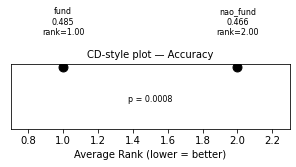


=== Metric: Kappa ===
Mean values: {'fund': -0.015826, 'nao_fund': -0.029012}
Mean ranks (lower = better): {'fund': 1.2222, 'nao_fund': 1.7778}
Nemenyi p-matrix:
           0         1
0  1.000000  0.095582
1  0.095582  1.000000
Paired t-test: stat=3.0026, p=0.017003 (normality p=0.7384)


/home/jjos/.local/lib/python3.6/site-packages/ipykernel_launcher.py:116: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 


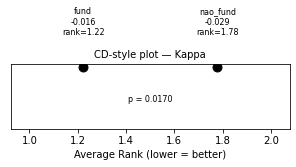

/home/jjos/.local/lib/python3.6/site-packages/ipykernel_launcher.py:116: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 



=== Metric: AUC ===
Mean values: {'fund': 0.477872, 'nao_fund': 0.477761}
Mean ranks (lower = better): {'fund': 1.4444, 'nao_fund': 1.5556}
Nemenyi p-matrix:
           0         1
0  1.000000  0.748645
1  0.748645  1.000000
Paired t-test: stat=0.0304, p=0.976487 (normality p=0.5233)


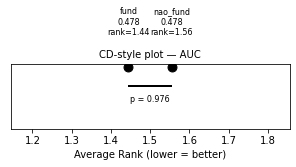


=== Metric: G-Mean ===
Mean values: {'fund': 0.447382, 'nao_fund': 0.427655}
Mean ranks (lower = better): {'fund': 1.0, 'nao_fund': 2.0}
Nemenyi p-matrix:
           0         1
0  1.000000  0.002699
1  0.002699  1.000000
Paired t-test: stat=6.2348, p=0.000250 (normality p=0.6819)


/home/jjos/.local/lib/python3.6/site-packages/ipykernel_launcher.py:116: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 


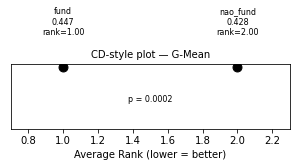

categoria      fund  nao_fund
fh                           
1          0.466086  0.446152
30         0.449062  0.447734
60         0.454518  0.438450
90         0.451104  0.440308
120        0.450496  0.431993
150        0.456328  0.425202
180        0.448107  0.418958
210        0.432469  0.405376
240        0.418264  0.394723
[[0.46608647 0.44615162]
 [0.44906186 0.44773439]
 [0.45451839 0.43845049]
 [0.45110354 0.44030753]
 [0.45049649 0.43199304]
 [0.45632818 0.42520163]
 [0.44810731 0.41895819]
 [0.43246932 0.4053756 ]
 [0.41826414 0.39472307]]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata, ttest_rel, wilcoxon, shapiro
import scikit_posthocs as sp

# ---------- CONFIG ----------
csv_path = "resultados/resultados_consolidados_20251113_010654.csv"
metrics = ['Accuracy', 'Kappa', 'AUC', 'G-Mean']
alpha = 0.05
# ----------------------------

df = pd.read_csv(csv_path)
df['categoria'] = df['categoria'].astype(str).str.lower().str.strip()

# Ensure we have the two categories named exactly as below (adjust if needed)
cat1 = 'fund'
cat2 = 'nao_fund'

# Quick check
print("Found categories:", df['categoria'].unique())
if not {cat1, cat2}.issubset(set(df['categoria'].unique())):
    raise ValueError(f"Expected categories '{cat1}' and '{cat2}' in column 'categoria'.")

# We'll create CD-like plots per metric
for metric in metrics:
    print("\n=== Metric:", metric, "===")
    # pivot: rows = dataset (or model), cols = category
    pivot = df.pivot_table(index='fh', columns='categoria', values=metric, aggfunc='mean')
    # Drop rows without both categories
    pivot = pivot.dropna(subset=[cat1, cat2])
    if pivot.shape[0] == 0:
        print("No paired rows for metric", metric, "- skipping.")
        continue

    # Data array: shape (n_datasets, n_methods)
    data = pivot[[cat1, cat2]].values  # order consistent
    datasets = pivot.index.tolist()
    methods = [cat1, cat2]

    # ---------- mean values and mean ranks ----------
    # We want ranks so that best (largest) -> rank 1
    # rankdata ranks 1..k with 1 = smallest by default, so we apply to -data per row
    ranks_per_row = np.apply_along_axis(lambda row: rankdata(-row, method='average'), axis=1, arr=data)
    mean_ranks = ranks_per_row.mean(axis=0)  # average rank per method
    mean_values = data.mean(axis=0)

    print("Mean values:", dict(zip(methods, mean_values.round(6))))
    print("Mean ranks (lower = better):", dict(zip(methods, mean_ranks.round(4))))

    # ---------- post-hoc / p-values ----------
    # scikit-posthocs expects array (n_datasets, n_methods)
    # For two methods, postenyi returns 2x2 p-matrix
    try:
        nemenyi_p = sp.posthoc_nemenyi_friedman(data)
        print("Nemenyi p-matrix:\n", nemenyi_p)
        # extract p between method0 and method1
        p_nemenyi = nemenyi_p.iloc[0,1]
    except Exception as e:
        print("Nemenyi failed:", e)
        p_nemenyi = np.nan

    # Also compute a paired t-test or Wilcoxon on the paired values (preferred)
    a = pivot[cat1].values
    b = pivot[cat2].values
    diff = a - b
    # normality test on differences
    try:
        p_shapiro = shapiro(diff).pvalue
    except Exception:
        p_shapiro = 0.0

    if p_shapiro > 0.05:
        test_name = 'Paired t-test'
        stat, p_pair = ttest_rel(a, b)
    else:
        test_name = 'Wilcoxon signed-rank'
        try:
            stat, p_pair = wilcoxon(a, b)
        except Exception:
            stat, p_pair = np.nan, np.nan

    print(f"{test_name}: stat={stat:.4f}, p={p_pair:.6f} (normality p={p_shapiro:.4f})")

    # ---------- Plot CD-like diagram ----------
    fig, ax = plt.subplots(figsize=(5,1.2))
    ax.set_title(f"CD-style plot — {metric}", fontsize=10)

    # positions = mean ranks
    x = mean_ranks
    y = np.zeros_like(x)

    # plot points
    ax.scatter(x, y, s=80, color='black', zorder=5)
    # text labels with mean value and rank
    for xi, mv, mname in zip(x, mean_values, methods):
        ax.text(xi, 0.08, f"{mname}\n{mv:.3f}\nrank={xi:.2f}",
                ha='center', fontsize=8)

    ax.hlines(y=-0.15, xmin=min(x)-0.2, xmax=max(x)+0.2, linewidth=0)  # spacing

    # connect non-significant pairs: here just one pair (cat1,cat2)
    # Use p_pair (paired test) as ground truth for significance
    if not np.isnan(p_pair) and p_pair >= alpha:
        # not significant -> draw connecting line between the two mean ranks
        xmin, xmax = min(x[0], x[1]), max(x[0], x[1])
        ax.hlines(y=-0.05, xmin=xmin, xmax=xmax, colors='black', linewidth=2)
        ax.text((xmin+xmax)/2, -0.09, f"p = {p_pair:.3f}", ha='center', fontsize=8)
    else:
        # significant -> annotate p
        ax.text((x[0]+x[1])/2, -0.09, f"p = {p_pair:.4f}", ha='center', fontsize=8)

    ax.set_yticks([])
    ax.set_xlabel("Average Rank (lower = better)")
    ax.set_xlim(min(x)-0.3, max(x)+0.3)
    plt.tight_layout()
    plt.show()

    # Done for this metric

print(pivot)
print(data)